# Predictive Analytics: Neural Network Baseline

This notebook trains one simple and reproducible neural-network baseline for each of the nine filtered datasets.

Model selection and all comparisons are performed on the validation split. The test split will only be used for the final evaluation after the grid search.

In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from run_config import MODELS_DIR, PATHS, demand_split_paths
from helper_functions import (
    collect_predictions,
    compute_regression_metrics,
    get_torch_device,
    load_model_from_checkpoint,
    plot_regression_diagnostics,
)

## Configuration

As target we select trip_count. We exclude date, month, weekday an hour and use cyclic encoded features instead. Further we exclude all other taxi-related columns to prevent leakage.

As batch size we select 1024, 100 epochs with a patience of 10 and a learning rate of 0.001 are used. Further we use seed 42 for reproduceability.

Hexagon datasets use H3 resolution 7.

In [ ]:
DATASET_CONFIGS = (
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "1h", "h3_resolution": 7},
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "1h"},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "1h"},
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "24h", "h3_resolution": 7},
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "24h"},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "24h"},
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "4h", "h3_resolution": 7},
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "4h"},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "4h"},
)

TARGET_COL = "trip_count"
TIME_COL = "datetime_hour"
MODEL_VERSION = "spatial_bias_v1"
MODEL_PATH = MODELS_DIR
MODEL_PATH.mkdir(parents=True, exist_ok=True)
BASELINE_PREDICTION_DIR = PATHS.train_test_dir / "baseline_predictions"

EXCLUDE_COLS = {
    TARGET_COL, TIME_COL, "date", "_split_bucket",
    "month", "weekday", "hour",  # cyclic variants are used instead
    # Pipeline-quality indicators are not demand drivers and may be unavailable in production
    "weather_qc_corrected", "station_observed", "weather_imputed", "precipitation_missing",
    # Taxi aggregates contain information about the target period and would cause leakage
    "trip_seconds_sum", "trip_seconds_mean", "trip_seconds_min", "trip_seconds_max",
    "trip_miles_sum", "trip_miles_mean", "trip_miles_min", "trip_miles_max",
    "fare_sum", "fare_mean", "fare_min", "fare_max",
    "tips_sum", "tips_mean", "tips_min", "tips_max",
    "tolls_sum", "tolls_mean", "tolls_min", "tolls_max",
    "extras_sum", "extras_mean", "extras_min", "extras_max",
    "trip_total_sum", "trip_total_mean", "trip_total_min", "trip_total_max",
    "most_common_payment_type",
}

BATCH_SIZE = 1024
EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 0.0
LEARNING_RATE = 0.001
BASE_SEED = 42


def split_paths_for(config):
    kwargs = {}
    if config["spatial_unit"] == "hexagon":
        kwargs["h3_resolution"] = config["h3_resolution"]
    return demand_split_paths(config["spatial_unit"], config["time_unit"], **kwargs)


def model_tag_for(config):
    if config["spatial_unit"] == "hexagon":
        return f"hexagon_h3r{config['h3_resolution']}_{config['time_unit']}"
    return f"{config['spatial_unit']}_{config['time_unit']}"

## Model architecture

We use a simple architecture with 2 hidden layers. As spatials IDs are categorical we use an embedding. Softplus guarantees non-negative demand predictions.

In [3]:
class TaxiDemandNN(nn.Module):
    def __init__(self, input_dim, num_spatial_units):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
        self.spatial_bias = nn.Embedding(
            num_embeddings=num_spatial_units + 1,
            embedding_dim=1,
            padding_idx=0,
        )
        nn.init.zeros_(self.spatial_bias.weight)
        self.output_activation = nn.Softplus()

    def forward(self, x, spatial_idx):
        return self.output_activation(self.network(x) + self.spatial_bias(spatial_idx))

## Reproducibility, validation and preprocessing

MSE is selected as the optimization loss, while validation MAE selects the checkpoint and drives early stopping as MAE is the primary metric.

In [ ]:
device = get_torch_device()
print("Using device:", device)


def set_reproducible_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Deterministic algorithms are requested where PyTorch supports them
    torch.use_deterministic_algorithms(True, warn_only=True)


def validate_model_frame(frame, feature_cols, spatial_col, split_name):
    required = {*feature_cols, spatial_col, TARGET_COL, "weekday", "hour"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing)}")
    if frame.is_empty():
        raise ValueError(f"{split_name} split is empty")
    selected = frame.select([*feature_cols, TARGET_COL])
    null_counts = selected.null_count().row(0, named=True)
    columns_with_nulls = [name for name, count in null_counts.items() if count]
    if columns_with_nulls:
        raise ValueError(f"{split_name} contains nulls in: {columns_with_nulls}")
    values = selected.to_numpy()
    if not np.issubdtype(values.dtype, np.number):
        raise TypeError(f"{split_name} model features and target must be numeric")
    if not np.isfinite(values).all():
        raise ValueError(f"{split_name} contains non-finite model values")


def encode_spatial(frame, spatial_col, spatial_to_idx):
    # The mapping is learned from TRAIN only. Unseen validation units map to 0
    return (
        frame.select(
            pl.col(spatial_col).cast(pl.String)
            .replace_strict(spatial_to_idx, default=0)
            .cast(pl.Int64).alias("spatial_idx")
        ).to_series().to_numpy()
    )


def make_loader(frame, feature_cols, spatial_col, spatial_to_idx, scaler, *, shuffle, seed):
    X = scaler.transform(frame.select(feature_cols).to_numpy()).astype("float32")
    spatial = encode_spatial(frame, spatial_col, spatial_to_idx)
    y = frame.select(TARGET_COL).to_numpy().astype("float32")
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(spatial, dtype=torch.long), torch.tensor(y)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
    )


def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for X_batch, spatial_batch, y_batch in train_loader:
        X_batch, spatial_batch, y_batch = X_batch.to(device), spatial_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch, spatial_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        total_samples += X_batch.size(0)
    return total_loss / total_samples


def evaluate_epoch(model, data_loader, criterion):
    model.eval()
    total_loss = total_absolute_error = total_squared_error = 0.0
    total_samples = 0
    with torch.inference_mode():
        for X_batch, spatial_batch, y_batch in data_loader:
            X_batch, spatial_batch, y_batch = X_batch.to(device), spatial_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch, spatial_batch)
            batch_size = X_batch.size(0)
            total_loss += criterion(y_pred, y_batch).item() * batch_size
            total_absolute_error += torch.abs(y_pred - y_batch).sum().item()
            total_squared_error += ((y_pred - y_batch) ** 2).sum().item()
            total_samples += batch_size
    return {
        "val_loss": total_loss / total_samples,
        "val_mae": total_absolute_error / total_samples,
        "val_rmse": math.sqrt(total_squared_error / total_samples),
    }

Using device: mps


## Fair validation baselines

The baseline predictions: zero, global-median and spatial × weekday × time are loaded from the artifacts created by the baseline notebook.

In [ ]:
BASELINE_PREDICTION_COLS = {
    "zero": "prediction_zero",
    "global_median": "prediction_global_median",
    "spatial_time_weekday_mean": "prediction_spatial_time_weekday_mean",
}
SKILL_SCORE_REFERENCE = "spatial_time_weekday_mean"


def load_validation_baseline_metrics(val_df, spatial_col, model_tag):
    # The trivial-baseline notebook fits on TRAIN and persists predictions for VAL
    # Loading that artifact keeps the baseline definition in one place.
    prediction_path = (
        BASELINE_PREDICTION_DIR / f"{model_tag}_val_baselines.parquet"
    )
    if not prediction_path.exists():
        raise FileNotFoundError(
            f"Validation baseline file not found: {prediction_path}. "
            "Run 03_01_predictive_analytics_baseline.ipynb first."
        )
    predictions = pl.read_parquet(prediction_path)
    required = {TIME_COL, spatial_col, "y_true", *BASELINE_PREDICTION_COLS.values()}
    missing = required.difference(predictions.columns)
    if missing:
        raise ValueError(f"Baseline file is missing columns: {sorted(missing)}")
    if predictions.height != val_df.height:
        raise ValueError(
            f"Baseline/validation row count differs: {predictions.height} != {val_df.height}"
        )

    # Verify that the artifact belongs to exactly this validation split, not
    # only to a dataset with the same number of rows
    key_cols = [TIME_COL, spatial_col]
    if predictions.select(key_cols).unique().height != predictions.height:
        raise ValueError(f"Baseline file contains duplicate keys: {prediction_path}")
    expected = val_df.select(
        *key_cols, pl.col(TARGET_COL).cast(pl.Float64).alias("expected_y_true")
    )
    aligned = expected.join(
        predictions.select(*key_cols, "y_true"), on=key_cols, how="left"
    )
    if aligned["y_true"].null_count():
        raise ValueError("Baseline file does not contain every validation key")
    max_target_difference = aligned.select(
        (pl.col("expected_y_true") - pl.col("y_true")).abs().max()
    ).item()
    if max_target_difference != 0.0:
        raise ValueError("Baseline file targets do not match the validation split")

    metrics = {}
    for baseline_name, prediction_col in BASELINE_PREDICTION_COLS.items():
        table = compute_regression_metrics(
            predictions.select("y_true", pl.col(prediction_col).alias("y_pred"))
        )
        metrics[baseline_name] = dict(zip(table["metric"].to_list(), table["value"].to_list()))
    return metrics

## Training and single-source evaluation

Here we use StandardScaler for the numeric features. The scaler is fitted only on the train data to avoid leakage. As Optimizer we use Adam 

MAE itself remains useful within a dataset, but for comparisons across spatial and temporal units, we normalize it against the baseline evaluated on the exact same validation rows

In [ ]:
def train_dataset_baseline(dataset_config, dataset_index):
    spatial_col = dataset_config["spatial_col"]
    model_tag = model_tag_for(dataset_config)
    split_paths = split_paths_for(dataset_config)
    seed = BASE_SEED + dataset_index
    set_reproducible_seed(seed)
    print(f"\n=== Training baseline: {model_tag} (seed={seed}) ===")

    train_df = pl.read_parquet(split_paths["train"])
    val_df = pl.read_parquet(split_paths["val"])
    feature_cols = [
        col for col in train_df.columns
        if col not in EXCLUDE_COLS and col != spatial_col
    ]
    validate_model_frame(train_df, feature_cols, spatial_col, "train")
    validate_model_frame(val_df, feature_cols, spatial_col, "validation")
    if train_df.select(feature_cols).schema != val_df.select(feature_cols).schema:
        raise TypeError("Train and validation feature schemas differ")

    spatial_values = sorted(
        train_df.select(pl.col(spatial_col).cast(pl.String)).to_series().unique().to_list()
    )
    spatial_to_idx = {value: index + 1 for index, value in enumerate(spatial_values)}

    # Fit all preprocessing on TRAIN only
    scaler = StandardScaler().fit(train_df.select(feature_cols).to_numpy())
    train_loader = make_loader(
        train_df, feature_cols, spatial_col, spatial_to_idx, scaler, shuffle=True, seed=seed
    )
    val_loader = make_loader(
        val_df, feature_cols, spatial_col, spatial_to_idx, scaler, shuffle=False, seed=seed
    )

    model_kwargs = {"input_dim": len(feature_cols), "num_spatial_units": len(spatial_to_idx)}
    model = TaxiDemandNN(**model_kwargs).to(device)
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = []
    best_val_mae = float("inf")
    epochs_without_improvement = 0
    checkpoint_path = MODEL_PATH / f"baseline_NN_{MODEL_VERSION}_{model_tag}_best_model.pt"

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate_epoch(model, val_loader, criterion)
        epoch_result = {"epoch": epoch, "train_loss": train_loss, **val_metrics}
        if not all(math.isfinite(value) for value in epoch_result.values()):
            raise RuntimeError(f"Non-finite metric detected for {model_tag} at epoch {epoch}")
        history.append(epoch_result)

        checkpoint = {
            **epoch_result,
            "selection_metric": "val_mae",
            "model_version": MODEL_VERSION,
            "model_tag": model_tag,
            "dataset_config": dict(dataset_config),
            "seed": seed,
            "batch_size": BATCH_SIZE,
            "feature_cols": feature_cols,
            "spatial_col": spatial_col,
            "spatial_to_idx": spatial_to_idx,
            "model_kwargs": model_kwargs,
            # Saving mean/scale avoids silently refitting preprocessing during inference
            "scaler_mean": scaler.mean_.tolist(),
            "scaler_scale": scaler.scale_.tolist(),
            "scaler_var": scaler.var_.tolist(),
            "scaler_n_features_in": int(scaler.n_features_in_),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        }
        if val_metrics["val_mae"] < best_val_mae - MIN_DELTA:
            best_val_mae = val_metrics["val_mae"]
            epochs_without_improvement = 0
            torch.save(checkpoint, checkpoint_path)
        else:
            epochs_without_improvement += 1

        print(
            f"{model_tag} | {epoch:03d}/{EPOCHS} | train MSE={train_loss:.4f} | "
            f"val MSE={val_metrics['val_loss']:.4f} | val MAE={val_metrics['val_mae']:.4f} | "
            f"val RMSE={val_metrics['val_rmse']:.4f} | stale={epochs_without_improvement}/{PATIENCE}"
        )
        if epochs_without_improvement >= PATIENCE:
            break

    history_df = pl.DataFrame(history)
    history_path = MODEL_PATH / f"baseline_NN_{MODEL_VERSION}_{model_tag}_training_history.parquet"
    history_df.write_parquet(history_path)

    # Reload and evaluate exactly the checkpoint selected by validation MAE
    best_model, checkpoint = load_model_from_checkpoint(TaxiDemandNN, checkpoint_path, device=device)
    val_predictions = collect_predictions(
        best_model, val_loader, device=device, embedding_input=True,
        inverse_target=lambda values: values,
    )
    nn_metrics_table = compute_regression_metrics(val_predictions)
    nn_metrics = dict(zip(nn_metrics_table["metric"].to_list(), nn_metrics_table["value"].to_list()))
    trivial_metrics = load_validation_baseline_metrics(val_df, spatial_col, model_tag)

    result_row = {
        "model_tag": model_tag,
        "model_version": MODEL_VERSION,
        "spatial_unit": dataset_config["spatial_unit"],
        "h3_resolution": dataset_config.get("h3_resolution"),
        "time_unit": dataset_config["time_unit"],
        "seed": seed,
        "best_epoch": checkpoint["epoch"],
        "nn_val_mae": nn_metrics["mae"],
        "nn_val_rmse": nn_metrics["rmse"],
        "nn_val_r2": nn_metrics["r2"],
    }
    for baseline_name, metrics in trivial_metrics.items():
        result_row[f"{baseline_name}_val_mae"] = metrics["mae"]
        result_row[f"{baseline_name}_val_rmse"] = metrics["rmse"]

    reference_mae = trivial_metrics[SKILL_SCORE_REFERENCE]["mae"]
    result_row["nn_val_mae_skill_score"] = (
        1.0 - nn_metrics["mae"] / reference_mae
        if reference_mae > 0.0
        else float("nan")
    )
    result_row["mae_skill_score_reference"] = SKILL_SCORE_REFERENCE

    return {
        "row": result_row,
        "checkpoint_path": checkpoint_path,
        "history_path": history_path,
        "history": history_df,
        "predictions": val_predictions,
        "metrics": nn_metrics_table,
    }

## Train all nine datasets and save the comparison table

Here we iterate over the datasets specified in dataset_configs and train the model on the datasets.

After the full trainings loop we store the results in one result table, showing the metrics of each run and allowing a comparison.

In [7]:
training_results = {}
result_rows = []

for dataset_index, dataset_config in enumerate(DATASET_CONFIGS):
    result = train_dataset_baseline(dataset_config, dataset_index)
    model_tag = result["row"]["model_tag"]
    training_results[model_tag] = result
    result_rows.append(result["row"])

results_df = pl.DataFrame(result_rows)
results_path = MODEL_PATH / f"baseline_NN_{MODEL_VERSION}_validation_results.parquet"
results_df.write_parquet(results_path)
print(f"Saved one-row-per-model validation comparison to {results_path}")
results_df.sort(["time_unit", "spatial_unit"])


=== Training baseline: hexagon_h3r7_1h (seed=42) ===
hexagon_h3r7_1h | 001/100 | train MSE=83.2336 | val MSE=52.0171 | val MAE=0.9580 | val RMSE=7.2123 | stale=0/10
hexagon_h3r7_1h | 002/100 | train MSE=45.9581 | val MSE=49.1959 | val MAE=0.8903 | val RMSE=7.0140 | stale=0/10
hexagon_h3r7_1h | 003/100 | train MSE=41.2571 | val MSE=42.7838 | val MAE=0.8713 | val RMSE=6.5409 | stale=0/10
hexagon_h3r7_1h | 004/100 | train MSE=39.0889 | val MSE=41.3326 | val MAE=0.8527 | val RMSE=6.4290 | stale=0/10
hexagon_h3r7_1h | 005/100 | train MSE=37.8857 | val MSE=40.5621 | val MAE=0.8613 | val RMSE=6.3688 | stale=1/10
hexagon_h3r7_1h | 006/100 | train MSE=36.7519 | val MSE=41.4654 | val MAE=0.8549 | val RMSE=6.4394 | stale=2/10
hexagon_h3r7_1h | 007/100 | train MSE=35.8549 | val MSE=39.0129 | val MAE=0.8382 | val RMSE=6.2460 | stale=0/10
hexagon_h3r7_1h | 008/100 | train MSE=34.9260 | val MSE=39.7670 | val MAE=0.8454 | val RMSE=6.3061 | stale=1/10
hexagon_h3r7_1h | 009/100 | train MSE=34.3288 | va

model_tag,model_version,spatial_unit,h3_resolution,time_unit,seed,best_epoch,nn_val_mae,nn_val_rmse,nn_val_r2,zero_val_mae,zero_val_rmse,global_median_val_mae,global_median_val_rmse,spatial_time_weekday_mean_val_mae,spatial_time_weekday_mean_val_rmse,nn_val_mae_skill_score,mae_skill_score_reference
str,str,str,i64,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""census_tracts_1h""","""spatial_bias_v1""","""census_tracts""",null,"""1h""",43,47,0.139574,1.510475,0.889589,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781,0.004251,"""spatial_time_weekday_mean"""
"""community_areas_1h""","""spatial_bias_v1""","""community_areas""",null,"""1h""",44,36,1.375832,7.54079,0.900319,4.173701,24.24616,4.173701,24.24616,1.285252,7.476175,-0.070477,"""spatial_time_weekday_mean"""
"""hexagon_h3r7_1h""","""spatial_bias_v1""","""hexagon""",7,"""1h""",42,73,0.75557,5.547422,0.898419,1.971626,17.516764,1.971626,17.516764,0.621958,5.160168,-0.214824,"""spatial_time_weekday_mean"""
"""census_tracts_24h""","""spatial_bias_v1""","""census_tracts""",null,"""24h""",46,99,3.341254,25.599396,0.901153,8.784738,81.895505,8.784738,81.895505,2.284586,23.092863,-0.462521,"""spatial_time_weekday_mean"""
"""community_areas_24h""","""spatial_bias_v1""","""community_areas""",null,"""24h""",47,1,100.984192,442.809082,-0.051192,100.168831,443.356247,100.168831,443.356247,23.603857,114.874738,-3.278292,"""spatial_time_weekday_mean"""
"""hexagon_h3r7_24h""","""spatial_bias_v1""","""hexagon""",7,"""24h""",45,100,15.075426,81.948151,0.934818,47.319018,324.448051,47.319018,324.448051,11.170743,79.849698,-0.349545,"""spatial_time_weekday_mean"""
"""census_tracts_4h""","""spatial_bias_v1""","""census_tracts""",null,"""4h""",49,65,0.5584,5.581751,0.896172,1.464123,17.384395,1.464123,17.384395,0.465925,5.400364,-0.198476,"""spatial_time_weekday_mean"""
"""community_areas_4h""","""spatial_bias_v1""","""community_areas""",null,"""4h""",50,62,5.419646,27.832962,0.90815,16.694805,93.342624,16.694805,93.342624,4.613278,26.828788,-0.174793,"""spatial_time_weekday_mean"""
"""hexagon_h3r7_4h""","""spatial_bias_v1""","""hexagon""",7,"""4h""",48,49,2.935158,19.904825,0.91227,7.886503,67.663431,7.886503,67.663431,2.209276,18.480618,-0.328561,"""spatial_time_weekday_mean"""


## Additional Plots

We plot for each dataset the regression_diagnostics, showing actual vs. predicted and performance in demand buckets


VALIDATION: hexagon_h3r7_1h
shape: (4, 2)
┌──────────┬───────────┐
│ metric   ┆ value     │
│ ---      ┆ ---       │
│ str      ┆ f64       │
╞══════════╪═══════════╡
│ mae      ┆ 0.75557   │
│ rmse     ┆ 5.547422  │
│ r2       ┆ 0.898419  │
│ peak_mae ┆ 37.624599 │
└──────────┴───────────┘


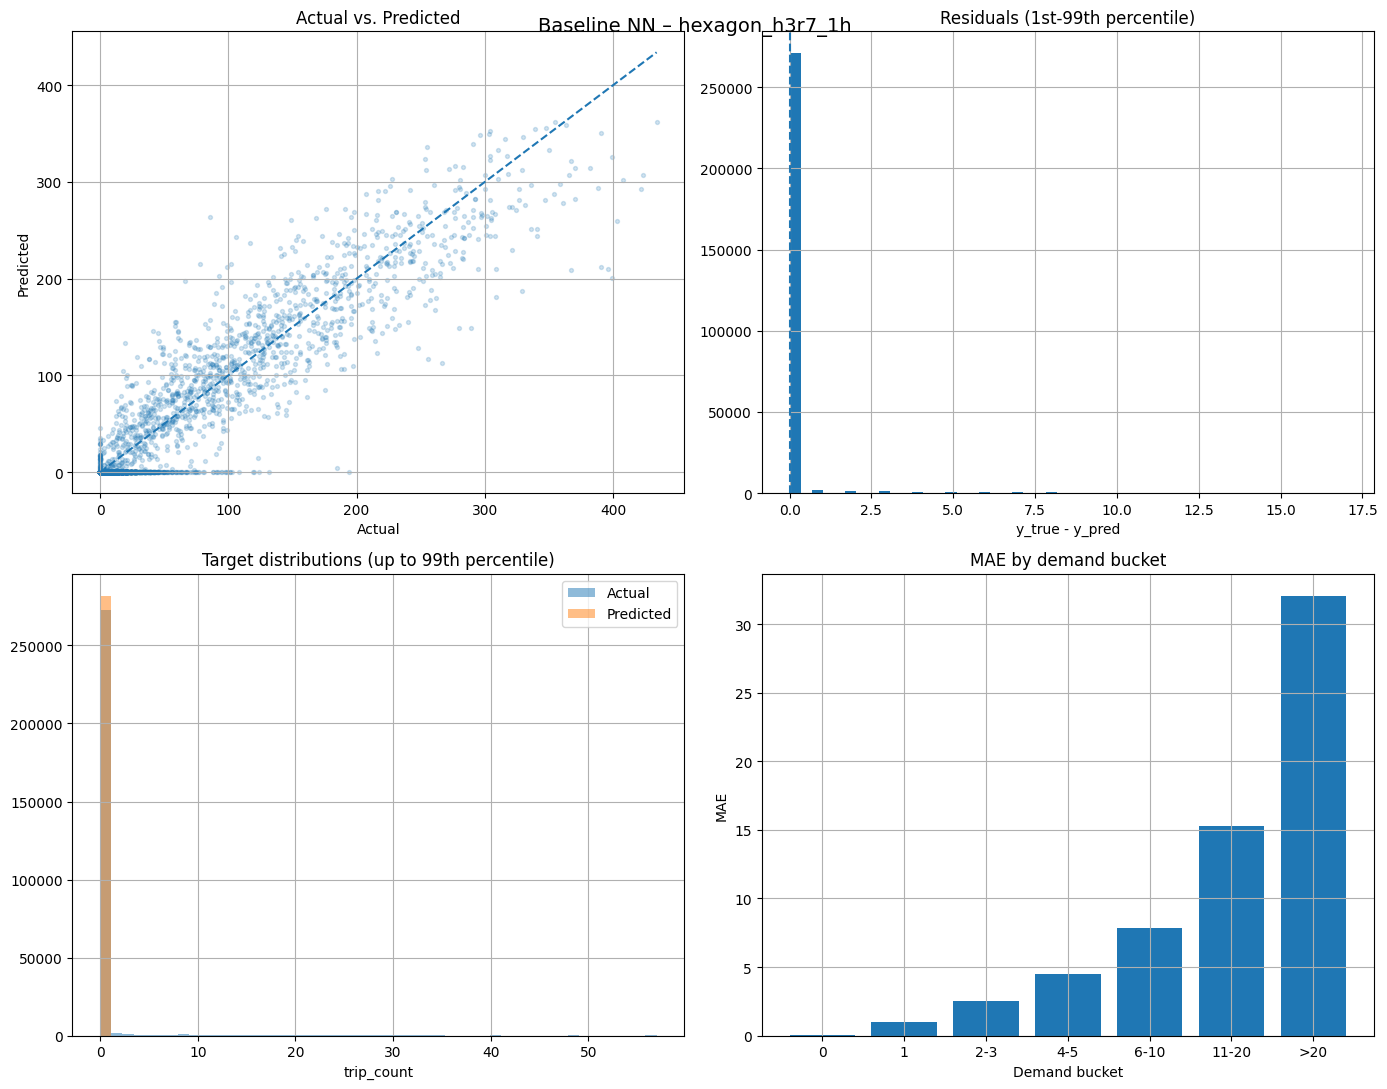

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 271111 ┆ 0.005997  ┆ 0.0        ┆ 0            │
│ 1             ┆ 1738   ┆ 1.013314  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 2652   ┆ 2.532733  ┆ 2.431373   ┆ 2            │
│ 4-5           ┆ 1282   ┆ 4.487744  ┆ 4.467239   ┆ 3            │
│ 6-10          ┆ 1978   ┆ 7.873723  ┆ 7.692619   ┆ 4            │
│ 11-20         ┆ 2036   ┆ 15.284778 ┆ 14.925344  ┆ 5            │
│ >20           ┆ 4779   ┆ 32.061424 ┆ 105.363464 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

VALIDATION: census_tracts_1h
shape: (4, 2)
┌──────────┬───────────┐
│ metric   ┆ value     │

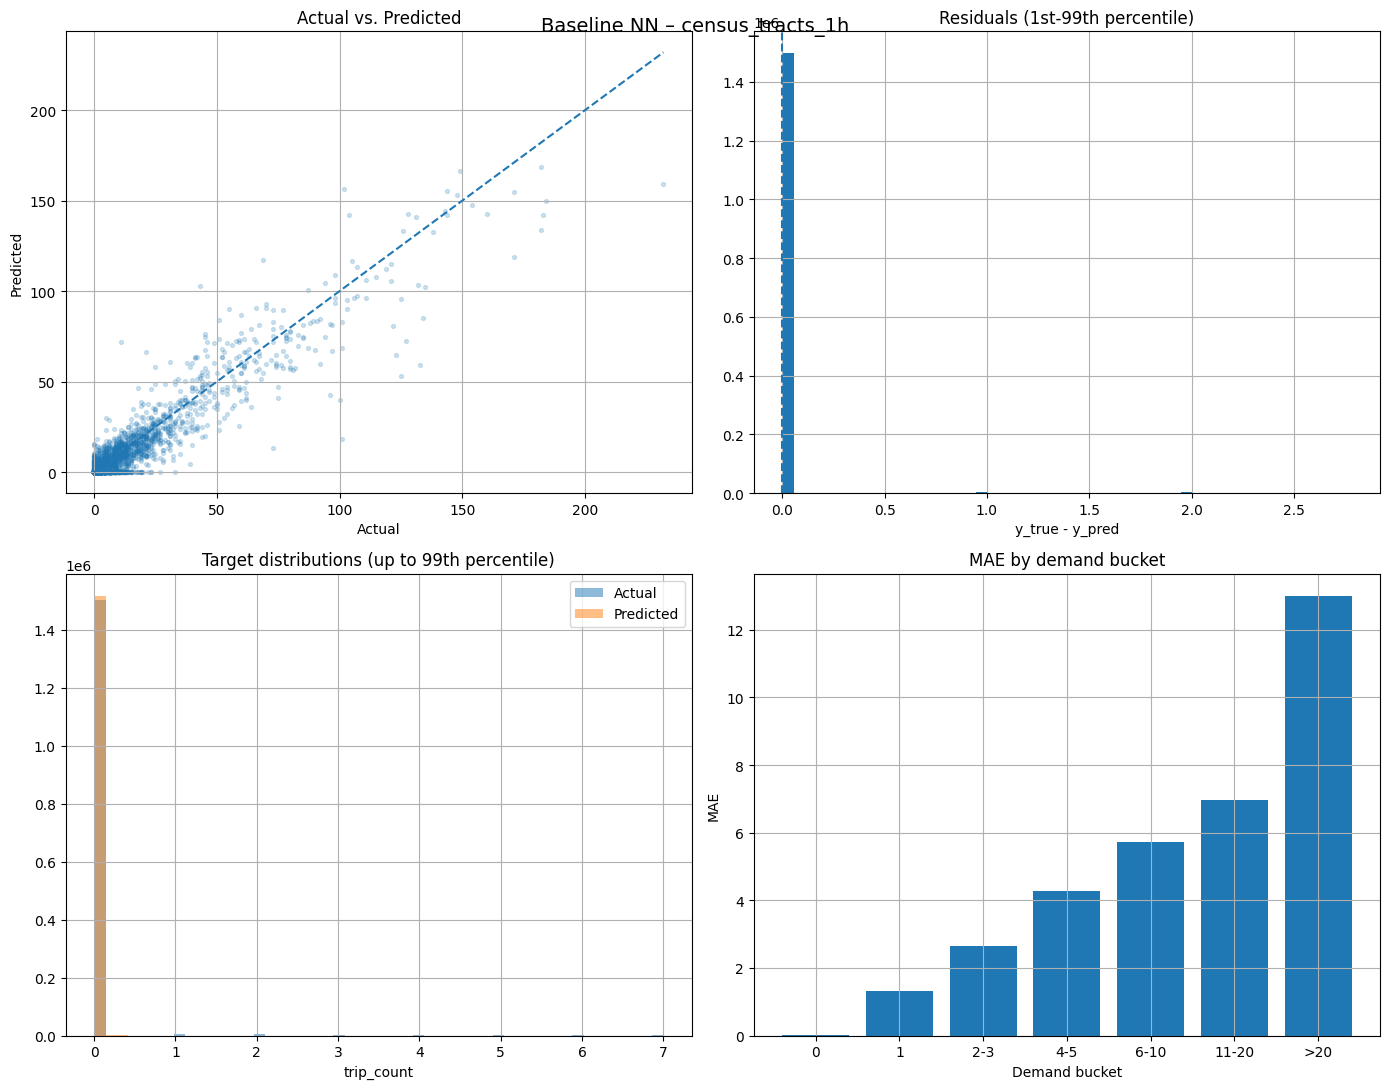

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬─────────┬──────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows  ┆ mae      ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---     ┆ ---      ┆ ---        ┆ ---          │
│ str           ┆ u32     ┆ f32      ┆ f32        ┆ i64          │
╞═══════════════╪═════════╪══════════╪════════════╪══════════════╡
│ 0             ┆ 1504607 ┆ 0.003688 ┆ 0.0        ┆ 0            │
│ 1             ┆ 3986    ┆ 1.317175 ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 7571    ┆ 2.655871 ┆ 2.439572   ┆ 2            │
│ 4-5           ┆ 3577    ┆ 4.2811   ┆ 4.466592   ┆ 3            │
│ 6-10          ┆ 5257    ┆ 5.722912 ┆ 7.749287   ┆ 4            │
│ 11-20         ┆ 5642    ┆ 6.972999 ┆ 14.88302   ┆ 5            │
│ >20           ┆ 7616    ┆ 13.00584 ┆ 52.50893   ┆ 6            │
└───────────────┴─────────┴──────────┴────────────┴──────────────┘

VALIDATION: community_areas_1h
shape: (4, 2)
┌──────────┬───────────┐
│ metric   ┆ value    

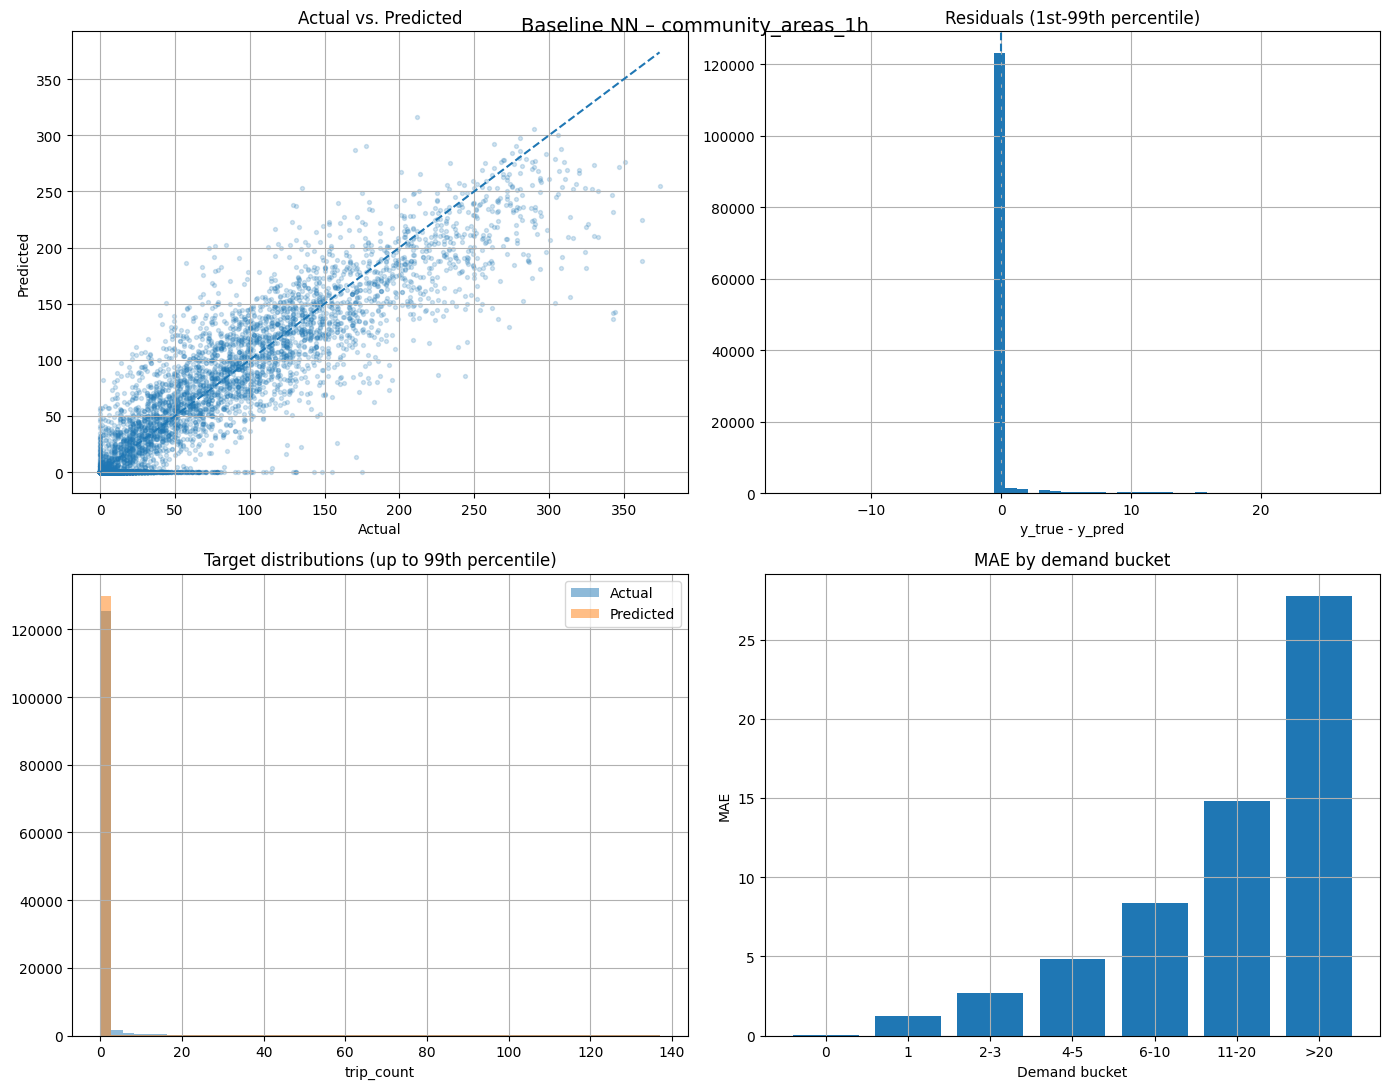

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 123124 ┆ 0.012359  ┆ 0.0        ┆ 0            │
│ 1             ┆ 1310   ┆ 1.21217   ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 1868   ┆ 2.671383  ┆ 2.40364    ┆ 2            │
│ 4-5           ┆ 839    ┆ 4.865335  ┆ 4.467223   ┆ 3            │
│ 6-10          ┆ 1293   ┆ 8.353772  ┆ 7.698376   ┆ 4            │
│ 11-20         ┆ 1311   ┆ 14.808666 ┆ 14.925248  ┆ 5            │
│ >20           ┆ 5159   ┆ 27.758837 ┆ 101.566193 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

VALIDATION: hexagon_h3r7_24h
shape: (4, 2)
┌──────────┬────────────┐
│ metric   ┆ value     

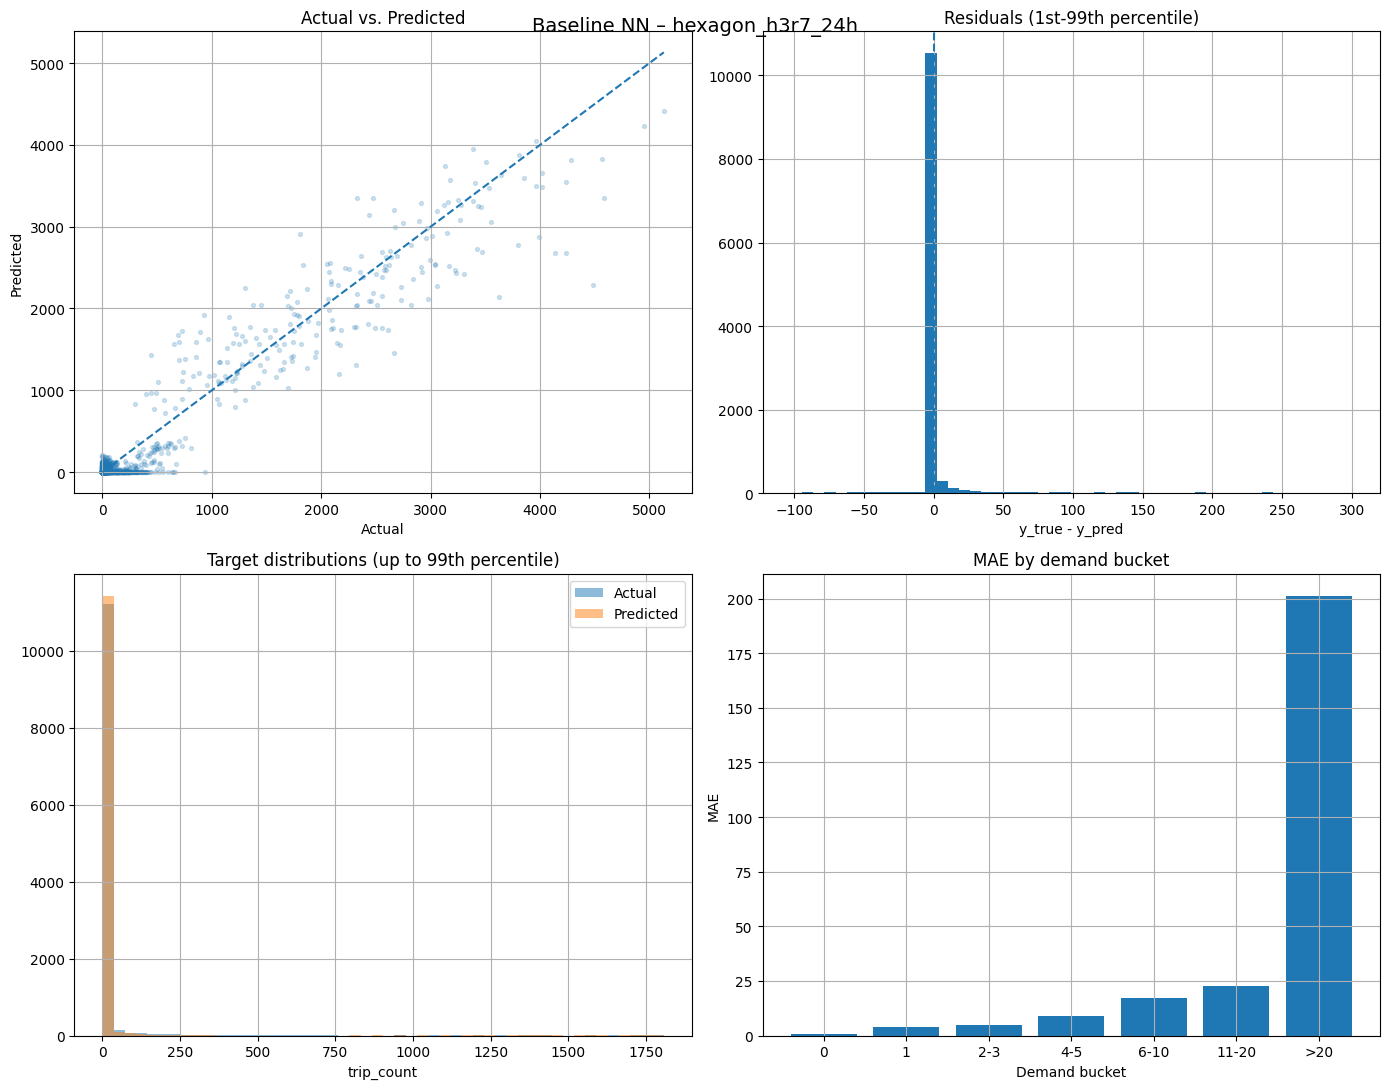

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬────────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae        ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---        ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32        ┆ f32        ┆ i64          │
╞═══════════════╪════════╪════════════╪════════════╪══════════════╡
│ 0             ┆ 10215  ┆ 0.533526   ┆ 0.0        ┆ 0            │
│ 1             ┆ 261    ┆ 3.838112   ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 241    ┆ 4.766127   ┆ 2.390042   ┆ 2            │
│ 4-5           ┆ 82     ┆ 8.835192   ┆ 4.402439   ┆ 3            │
│ 6-10          ┆ 119    ┆ 17.260851  ┆ 7.697479   ┆ 4            │
│ 11-20         ┆ 159    ┆ 22.526577  ┆ 14.603773  ┆ 5            │
│ >20           ┆ 822    ┆ 201.243149 ┆ 679.577881 ┆ 6            │
└───────────────┴────────┴────────────┴────────────┴──────────────┘

VALIDATION: census_tracts_24h
shape: (4, 2)
┌──────────┬────────────┐
│ metric 

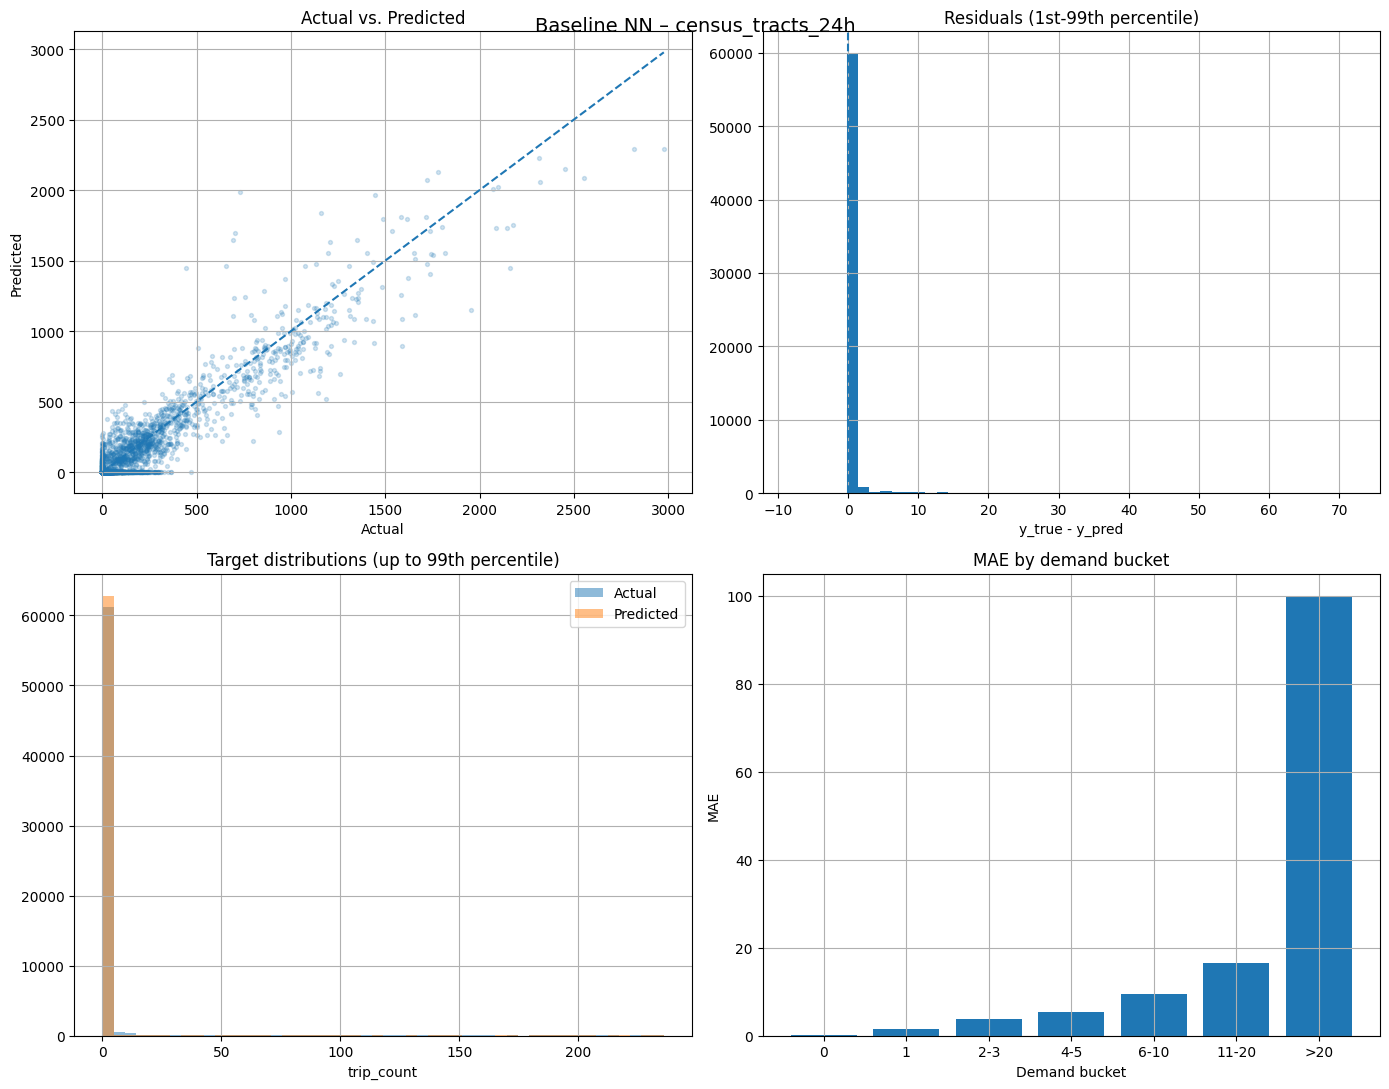

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 59459  ┆ 0.170319  ┆ 0.0        ┆ 0            │
│ 1             ┆ 657    ┆ 1.513529  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 867    ┆ 3.697907  ┆ 2.392157   ┆ 2            │
│ 4-5           ┆ 342    ┆ 5.327934  ┆ 4.441521   ┆ 3            │
│ 6-10          ┆ 465    ┆ 9.564028  ┆ 7.658064   ┆ 4            │
│ 11-20         ┆ 440    ┆ 16.489349 ┆ 14.754545  ┆ 5            │
│ >20           ┆ 1864   ┆ 99.947456 ┆ 294.391632 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

VALIDATION: community_areas_24h
shape: (4, 2)
┌──────────┬────────────┐
│ metric   ┆ value  

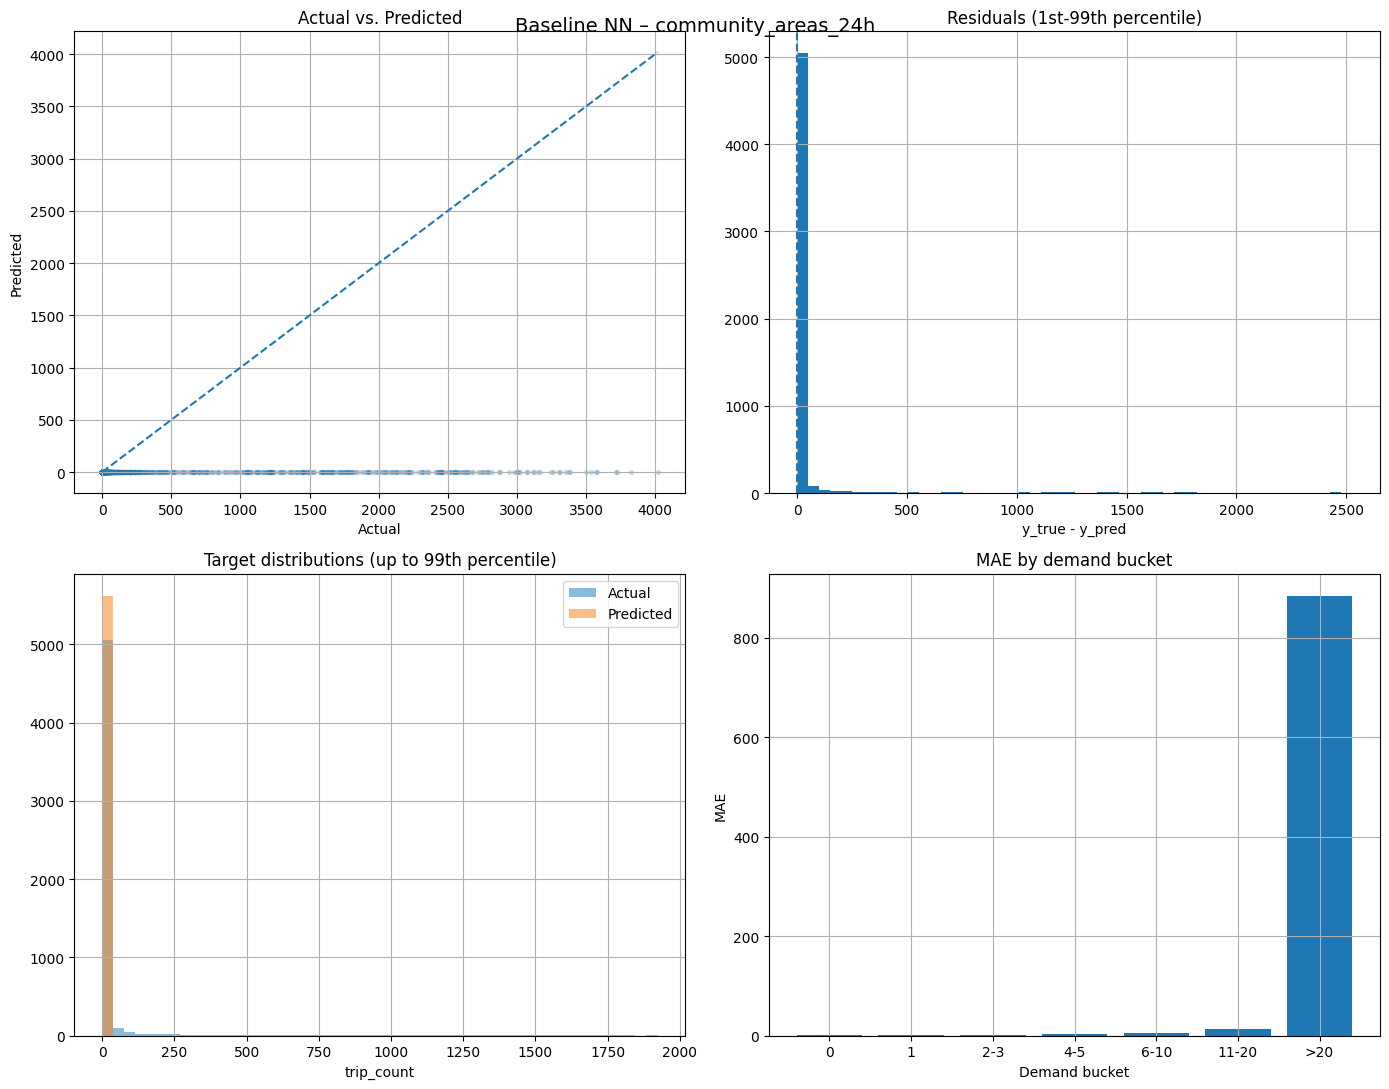

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬────────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae        ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---        ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32        ┆ f32        ┆ i64          │
╞═══════════════╪════════╪════════════╪════════════╪══════════════╡
│ 0             ┆ 4332   ┆ 1.557015   ┆ 0.0        ┆ 0            │
│ 1             ┆ 187    ┆ 0.602559   ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 206    ┆ 0.787661   ┆ 2.38835    ┆ 2            │
│ 4-5           ┆ 82     ┆ 2.582806   ┆ 4.292683   ┆ 3            │
│ 6-10          ┆ 94     ┆ 5.96829    ┆ 7.680851   ┆ 4            │
│ 11-20         ┆ 88     ┆ 12.879261  ┆ 14.647727  ┆ 5            │
│ >20           ┆ 632    ┆ 884.028564 ┆ 886.087036 ┆ 6            │
└───────────────┴────────┴────────────┴────────────┴──────────────┘

VALIDATION: hexagon_h3r7_4h
shape: (4, 2)
┌──────────┬───────────┐
│ metric   ┆

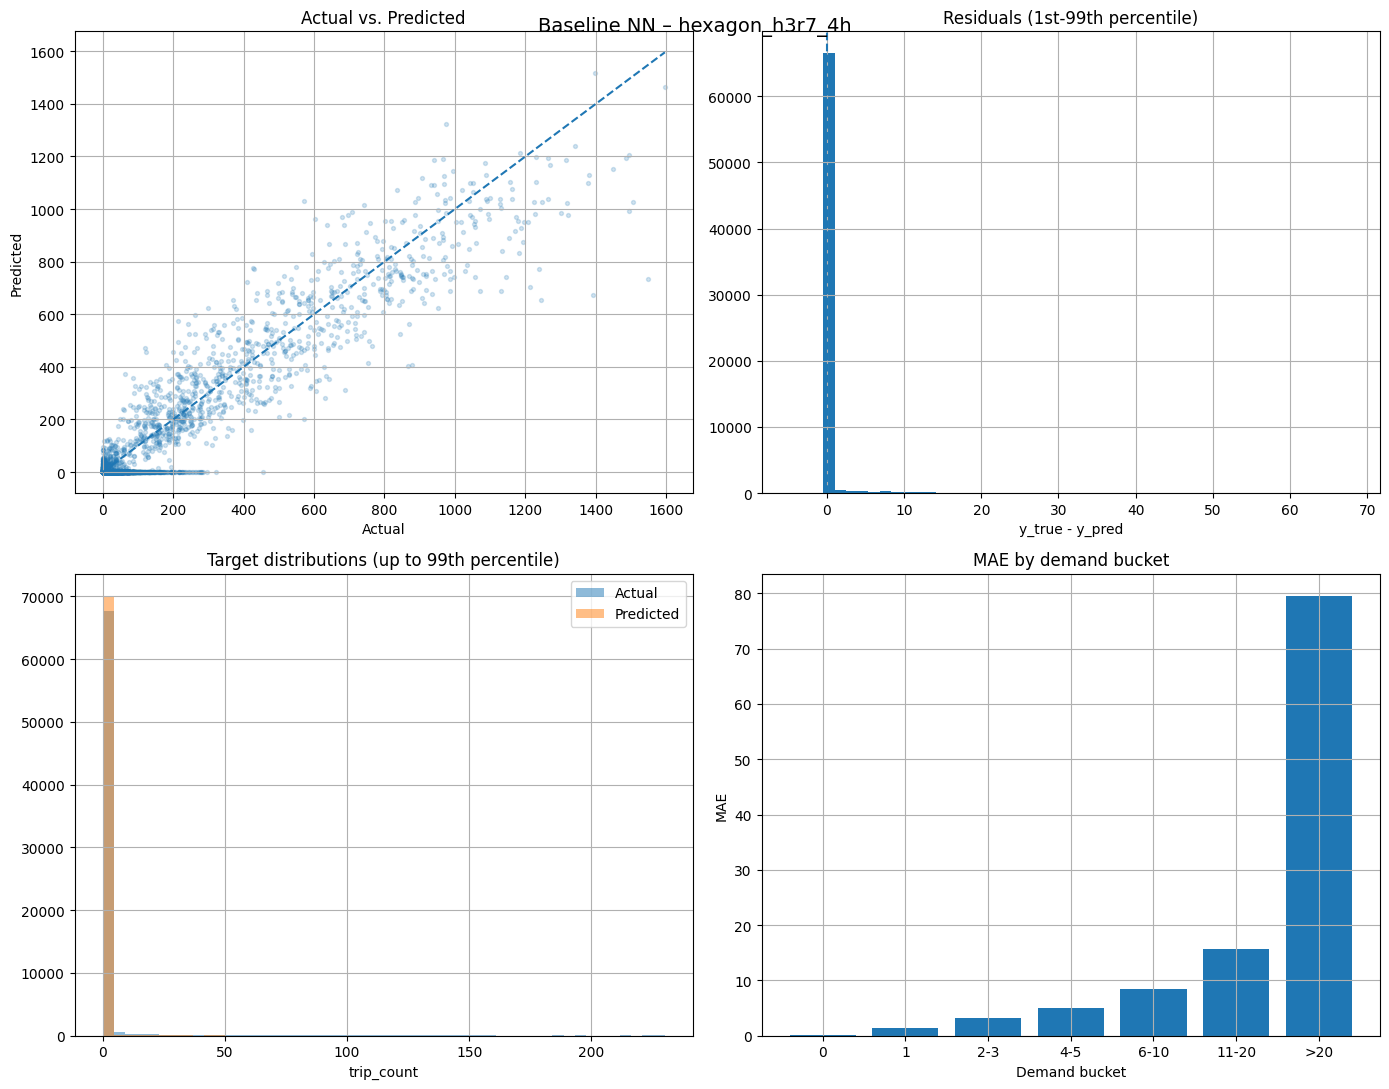

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 66005  ┆ 0.036094  ┆ 0.0        ┆ 0            │
│ 1             ┆ 671    ┆ 1.459905  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 831    ┆ 3.206664  ┆ 2.423586   ┆ 2            │
│ 4-5           ┆ 358    ┆ 4.963393  ┆ 4.441341   ┆ 3            │
│ 6-10          ┆ 560    ┆ 8.348477  ┆ 7.746428   ┆ 4            │
│ 11-20         ┆ 613    ┆ 15.689261 ┆ 14.85155   ┆ 5            │
│ >20           ┆ 2356   ┆ 79.565529 ┆ 231.465195 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

VALIDATION: census_tracts_4h
shape: (4, 2)
┌──────────┬───────────┐
│ metric   ┆ value     │

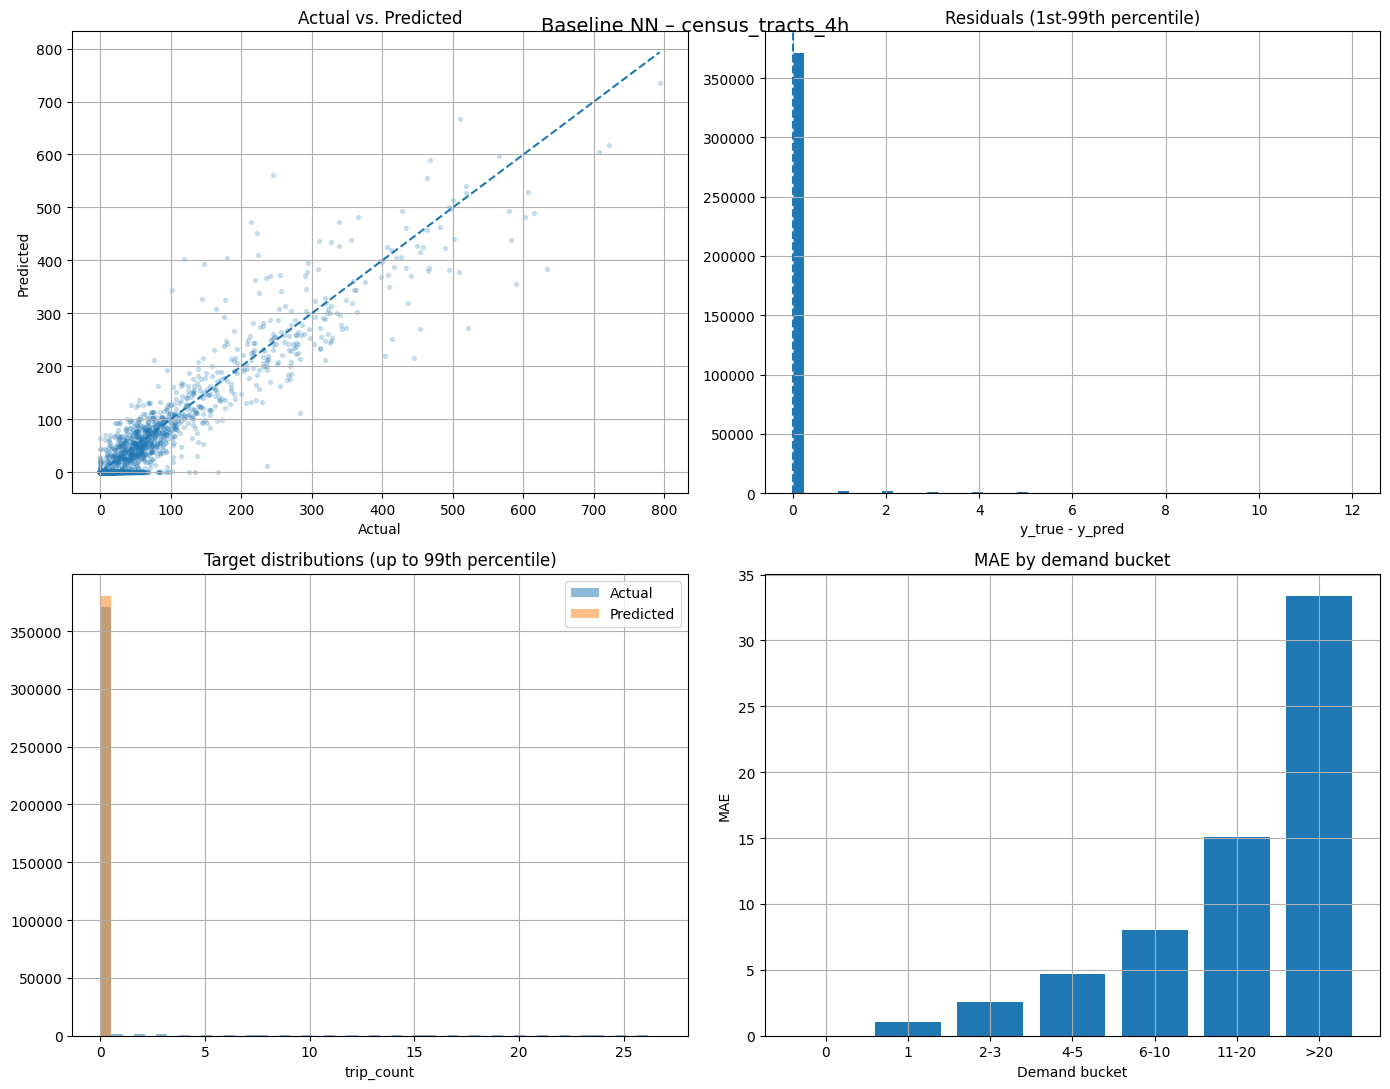

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 371093 ┆ 0.004026  ┆ 0.0        ┆ 0            │
│ 1             ┆ 1684   ┆ 1.057755  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 2632   ┆ 2.550606  ┆ 2.431991   ┆ 2            │
│ 4-5           ┆ 1099   ┆ 4.695643  ┆ 4.454049   ┆ 3            │
│ 6-10          ┆ 1613   ┆ 7.992818  ┆ 7.641042   ┆ 4            │
│ 11-20         ┆ 1554   ┆ 15.098422 ┆ 14.823681  ┆ 5            │
│ >20           ┆ 4889   ┆ 33.388474 ┆ 105.278786 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

VALIDATION: community_areas_4h
shape: (4, 2)
┌──────────┬───────────┐
│ metric   ┆ value    

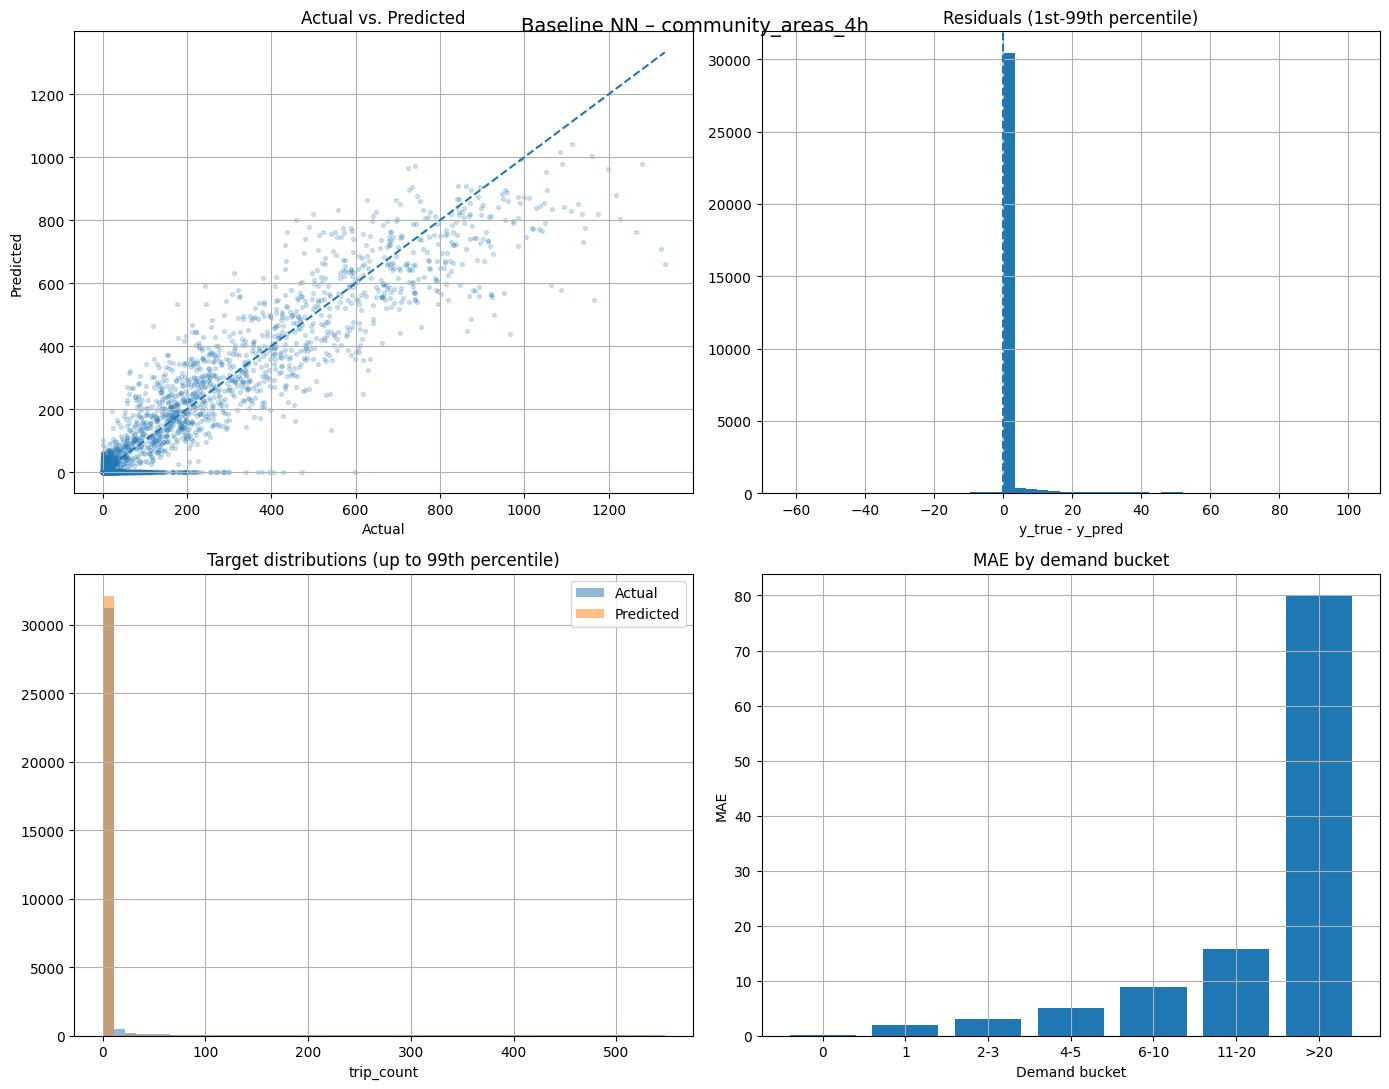

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 29492  ┆ 0.078127  ┆ 0.0        ┆ 0            │
│ 1             ┆ 504    ┆ 1.865516  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 612    ┆ 3.080031  ┆ 2.379085   ┆ 2            │
│ 4-5           ┆ 229    ┆ 5.065431  ┆ 4.467249   ┆ 3            │
│ 6-10          ┆ 380    ┆ 8.87144   ┆ 7.692105   ┆ 4            │
│ 11-20         ┆ 427    ┆ 15.663548 ┆ 14.733021  ┆ 5            │
│ >20           ┆ 2082   ┆ 79.93956  ┆ 264.578278 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘


In [8]:
for model_tag, result in training_results.items():
    print("\n" + "=" * 80)
    print(f"VALIDATION: {model_tag}")
    print(result["metrics"].filter(pl.col("metric").is_in(["mae", "rmse", "r2", "peak_mae"])))
    figure, bucket_metrics = plot_regression_diagnostics(result["predictions"])
    figure.suptitle(f"Baseline NN – {model_tag}", fontsize=14)
    plt.show()
    print("MAE by demand bucket:")
    print(bucket_metrics)

# Findings

With this architecture only census_tract 1h predicts slightly better than the naive baseline of avg of spatial x time x weekday. Therefore it seems that the more dense spatial and time units help the modell to pick up additional structure in the data. 

The main problem is like expected the sparse data with many 0 demand buckets. It is very easy for the model to learn 0 prediction and 0 predictions drive the MAE down.
However, it is much harder for the model to learn high demand predictions as there is much less data.

24h datasets are performing the worsest, but also contain much less data compared to 1h and 4h.

Based on these findings we decide to focus on the most promising dataset: census_tract 1h. The focus should be to improve the performance for "real" demand buckets.

In the next notebook we perform a grid search. As the runtime for a single trainingsrun is large, for a large grid search it may explode. Therefore we 
try to minimize the grid search as much as possible. To do so we also look at how many epochs might be sufficient for a first guess of the model performance. 20 epochs look sufficient.

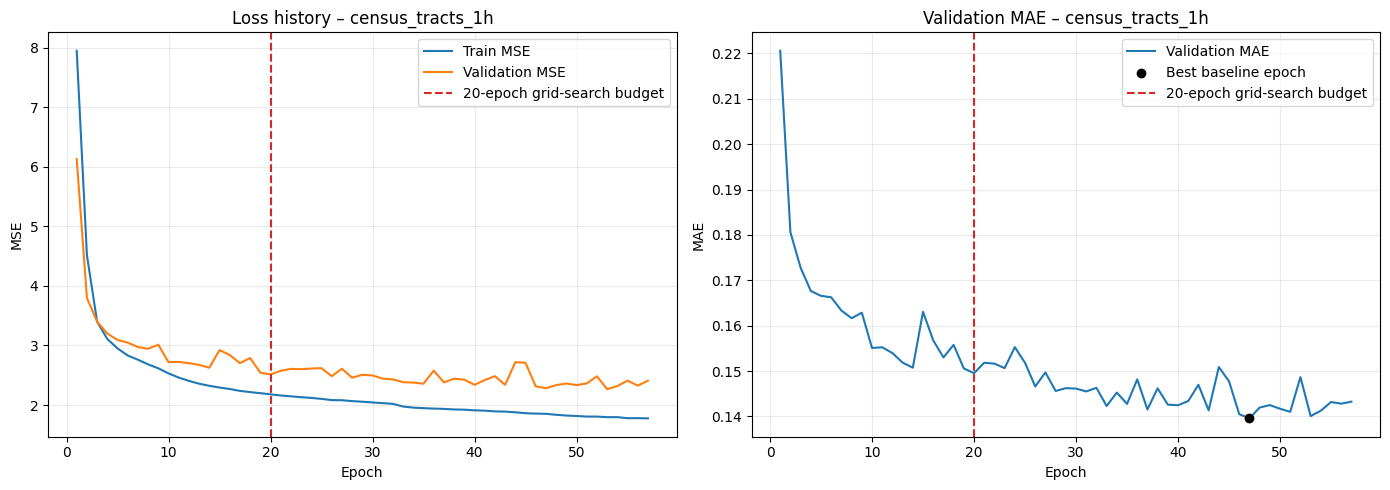

In [10]:
HISTORY_MODEL_TAG = "census_tracts_1h"
EPOCH_BUDGET_TO_CHECK = 20

if HISTORY_MODEL_TAG not in training_results:
    raise KeyError(
        f"No training result for {HISTORY_MODEL_TAG}. Run the training cell first."
    )

census_1h_history = training_results[HISTORY_MODEL_TAG]["history"].sort("epoch")
history_through_budget = census_1h_history.filter(
    pl.col("epoch") <= EPOCH_BUDGET_TO_CHECK
)
if history_through_budget.is_empty():
    raise ValueError("The training history contains no epochs within the requested budget")

best_overall = census_1h_history.sort("val_mae").row(0, named=True)
best_through_budget = history_through_budget.sort("val_mae").row(0, named=True)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(
    census_1h_history["epoch"], census_1h_history["train_loss"],
    label="Train MSE",
)
axes[0].plot(
    census_1h_history["epoch"], census_1h_history["val_loss"],
    label="Validation MSE",
)
axes[0].set(title="Loss history – census_tracts_1h", xlabel="Epoch", ylabel="MSE")
axes[0].legend()

axes[1].plot(
    census_1h_history["epoch"], census_1h_history["val_mae"],
    label="Validation MAE",
)
axes[1].scatter(
    [best_overall["epoch"]], [best_overall["val_mae"]],
    color="black", zorder=3, label="Best baseline epoch",
)
axes[1].set(title="Validation MAE – census_tracts_1h", xlabel="Epoch", ylabel="MAE")
axes[1].legend()

for axis in axes:
    axis.axvline(
        EPOCH_BUDGET_TO_CHECK, color="tab:red", linestyle="--",
        label="20-epoch grid-search budget",
    )
    axis.grid(alpha=0.25)
    axis.legend()

figure.tight_layout()
plt.show()
